# Exploratory Analysis

The goal of this notebook is to evaluate the EPA-based value metrics created in `03_value_score_engineering.ipynb` and decide whether they behave sensibly before moving into predictive modeling or salary-efficiency analysis.

The main raw production metric is `value_epa_total`, which estimates how many expected points a player added over the full season. The notebook also keeps `value_epa_per_game`, which measures production when active. These answer different questions: total EPA rewards full-season contribution, while EPA per game highlights players who were efficient or productive in fewer games.

The standardized columns, `value_score` and `value_score_per_game`, are comparison tools. They show how far above or below a player was relative to others at the same position in the same season. They are useful for cross-season and within-position ranking, but the raw EPA columns are easier to interpret directly.


## Load Value Scores

This section loads the value-score dataset created in notebook 3. Each row represents one player-season-team that passed the minimum games-played filter. The path logic is written so the notebook can run from either the project root or the `notebooks/` folder.


In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def find_project_root(expected_file):
    """Find the repo root from common VS Code/Jupyter working directories."""
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / expected_file).exists():
            return candidate
    raise FileNotFoundError(
        "Could not find " + expected_file + " from working directory " + str(Path.cwd())
    )

project_root = find_project_root("data/processed/player_value_scores_2016_2025.csv")
processed_dir = project_root / "data" / "processed"
figures_dir = project_root / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

value_scores_path = processed_dir / "player_value_scores_2016_2025.csv"
value_scored = pd.read_csv(value_scores_path)

print(value_scored.shape)
value_scored.head()


(4796, 84)


,season,player_id,player_name,player_display_name,position,team,completions,attempts,passing_yards,passing_tds,...,value_epa_total,value_epa_per_game,value_score_total_epa,value_score_per_game,value_score,value_metric,scrimmage_epa_z,scrimmage_epa_per_game_z,position_season_rank,position_season_percentile
0,2016,00-0019596,T.Brady,Tom Brady,QB,NE,291,432,3554,28,...,140.632333,11.719361,2.127596,2.264787,2.127596,position_adjusted_total_epa,NaN,NaN,3.0,0.96
1,2016,00-0020531,D.Brees,Drew Brees,QB,NO,471,673,5208,37,...,105.672159,6.604510,1.491620,1.172466,1.491620,position_adjusted_total_epa,NaN,NaN,6.0,0.90
2,2016,00-0021206,J.McCown,Josh McCown,QB,CLE,90,165,1100,6,...,-29.051473,-5.810295,-0.959196,-1.478825,-0.959196,position_adjusted_total_epa,NaN,NaN,45.0,0.12
3,2016,00-0021429,C.Palmer,Carson Palmer,QB,ARI,364,597,4233,26,...,26.261320,1.750755,0.047023,0.135903,0.047023,position_adjusted_total_epa,NaN,NaN,20.0,0.62
4,2016,00-0022803,E.Manning,Eli Manning,QB,NYG,377,598,4027,26,...,-20.212029,-1.263252,-0.798394,-0.507764,-0.798394,position_adjusted_total_epa,NaN,NaN,41.0,0.20


## Quick Data Checks

Before interpreting any charts, confirm that the dataset has the expected metric columns and no duplicate player-season-team rows. This matters because duplicate rows or missing metric columns would distort ranks, distributions, and model inputs later.

The key columns to check are the raw value metrics (`value_epa_total`, `value_epa_per_game`) and the standardized comparison metrics (`value_score`, `value_score_per_game`).


In [2]:
required_cols = [
    "season", "player_id", "player_display_name", "position", "team",
    "games_played", "value_epa_total", "value_epa_per_game",
    "value_score", "value_score_per_game",
    "position_season_rank", "position_season_percentile"
]

missing_cols = [col for col in required_cols if col not in value_scored.columns]
print("Missing columns:", missing_cols)

duplicate_rows = value_scored.duplicated(["season", "player_id", "team"]).sum()
print("Duplicate player-season-team rows:", duplicate_rows)

print("Seasons:", sorted(value_scored["season"].dropna().unique()))
print("Positions:", value_scored["position"].value_counts().to_dict())

value_scored[[
    "value_epa_total", "value_epa_per_game", "value_score", "value_score_per_game"
]].describe()


Missing columns: []
Duplicate player-season-team rows: 0
Seasons: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Positions: {'WR': 1962, 'RB': 1244, 'TE': 1040, 'QB': 550}


,value_epa_total,value_epa_per_game,value_score,value_score_per_game
count,4796.000000,4796.000000,4.796000e+03,4.796000e+03
mean,6.813946,0.372689,-1.851915e-18,7.407660e-18
std,26.228524,2.092860,9.959250e-01,9.959250e-01
min,-146.750158,-14.526440,-6.127502e+00,-4.539718e+00
25%,-4.362987,-0.470570,-6.067509e-01,-6.207411e-01
50%,2.008182,0.207548,-1.852841e-01,-8.916565e-02
75%,13.173117,1.134389,4.586354e-01,5.542435e-01
max,237.035261,14.814704,6.153515e+00,5.577377e+00


## Add Diagnostic Columns

`value_score_gap` compares per-game standardized value to total-EPA standardized value.

A large positive gap usually means a player looked better on a per-game basis than as a full-season contributor. That can happen when a player missed games, had a smaller role, or produced efficiently on limited volume. A large negative gap can indicate a player accumulated value through availability and volume even if the per-game rate was less exceptional.

This diagnostic is important because it directly tests whether EPA per game is telling a different story from total EPA.


In [3]:
value_scored = value_scored.copy()
value_scored["value_score_gap"] = value_scored["value_score_per_game"] - value_scored["value_score"]

value_scored[[
    "player_display_name", "season", "position", "team", "games_played",
    "value_epa_total", "value_epa_per_game", "value_score",
    "value_score_per_game", "value_score_gap"
]].sort_values("value_score_gap", ascending=False).head(10)


,player_display_name,season,position,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game,value_score_gap
4374,Tyreek Hill,2025,WR,MIA,4,19.834595,4.958649,0.510285,3.125714,2.615429
4279,Rashee Rice,2024,WR,KC,4,18.822884,4.705721,0.353891,2.602922,2.249031
2701,Maxx Williams,2021,TE,ARI,5,15.071474,3.014295,0.660362,2.667580,2.007218
2414,Kenny Golladay,2020,WR,DET,5,21.662457,4.332491,0.329387,2.181860,1.852473
2642,Antonio Brown,2021,WR,TB,7,34.262215,4.894602,1.122572,2.849496,1.726924
3990,Chris Godwin Jr.,2024,WR,TB,7,37.047007,5.292430,1.272327,2.996180,1.723854
2060,Will Dissly,2019,TE,SEA,6,19.106299,3.184383,0.816342,2.527502,1.711160
4649,Tucker Kraft,2025,TE,GB,8,38.442761,4.805345,2.054956,3.671043,1.616086
4732,Ashton Jeanty,2025,RB,LV,17,-77.057753,-4.532809,-6.127502,-4.539718,1.587784
4711,Jalen McMillan,2025,WR,TB,4,12.027500,3.006875,0.091477,1.670289,1.578812


## Top Full-Season Value By Position

These tables use `value_epa_total`, the raw full-season EPA metric. This is the clearest measure of season-level production: how many expected points the player added over the year.

This is the best place to start for future salary-efficiency analysis because salaries and cap hits are season-level costs. A player who is elite per game but misses a large part of the season may still provide less total season value than a player who is slightly less efficient but available every week.


In [4]:
season_to_check = 2024

for pos in ["QB", "RB", "WR", "TE"]:
    print()
    print("Top", pos + "s", "by total EPA in", season_to_check)
    display(
        value_scored[
            (value_scored["season"] == season_to_check) &
            (value_scored["position"] == pos)
        ][[
            "player_display_name", "team", "games_played",
            "value_epa_total", "value_epa_per_game",
            "value_score", "position_season_rank"
        ]]
        .sort_values("value_epa_total", ascending=False)
        .head(10)
    )



Top QBs by total EPA in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,position_season_rank
451,Josh Allen,BUF,16,187.113574,11.694598,2.753053,1.0
449,Lamar Jackson,BAL,17,183.931545,10.819503,2.701035,2.0
441,Jared Goff,DET,17,165.429827,9.731166,2.398578,3.0
462,Joe Burrow,CIN,17,131.179774,7.716457,1.838674,4.0
450,Baker Mayfield,TB,17,122.182661,7.187215,1.691593,5.0
484,Jayden Daniels,WAS,17,119.373123,7.021948,1.645664,6.0
468,Brock Purdy,SF,15,97.007326,6.467155,1.280039,7.0
447,Patrick Mahomes,KC,16,95.446626,5.965414,1.254526,8.0
458,Tua Tagovailoa,MIA,11,86.305197,7.845927,1.105086,9.0
453,Kyler Murray,ARI,17,83.587614,4.916918,1.060660,10.0



Top RBs by total EPA in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,position_season_rank
4282,Jahmyr Gibbs,DET,17,50.032154,2.943068,3.307019,1.0
3955,Derrick Henry,BAL,17,49.606434,2.918026,3.281219,2.0
4026,Saquon Barkley,PHI,16,49.461172,3.091323,3.272415,3.0
4295,Bucky Irving,TB,17,35.450351,2.085315,2.423312,4.0
4220,Bijan Robinson,ATL,17,25.584958,1.504998,1.825435,5.0
4051,Ty Johnson,BUF,17,24.069822,1.415872,1.733613,6.0
4161,James Cook,BUF,16,23.395136,1.462196,1.692724,7.0
3979,Austin Ekeler,WAS,12,18.801500,1.566792,1.414334,8.0
4261,Sean Tucker,TB,17,17.547465,1.032204,1.338336,9.0
4032,Justice Hill,BAL,15,14.844525,0.989635,1.174528,10.0



Top WRs by total EPA in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,position_season_rank
4140,Amon-Ra St. Brown,DET,17,95.743892,5.631994,4.230455,1.0
4133,Ja'Marr Chase,CIN,17,79.032173,4.648951,3.388240,2.0
4344,Ladd McConkey,LAC,16,65.707443,4.106715,2.716718,3.0
4060,Terry McLaurin,WAS,17,64.637547,3.802209,2.662798,4.0
4089,Justin Jefferson,MIN,17,63.974392,3.763200,2.629377,5.0
4061,A.J. Brown,PHI,13,61.811166,4.754705,2.520358,6.0
4339,Brian Thomas Jr.,JAX,17,56.810445,3.341791,2.268338,7.0
4097,Tee Higgins,CIN,12,56.401296,4.700108,2.247719,8.0
4136,DeVonta Smith,PHI,13,56.324606,4.332662,2.243854,9.0
4281,Puka Nacua,LA,11,54.491021,4.953729,2.151447,10.0



Top TEs by total EPA in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,position_season_rank
3965,George Kittle,SF,15,67.944928,4.529662,4.122215,1.0
3982,Jonnu Smith,MIA,17,58.068716,3.415807,3.436751,2.0
4017,Mark Andrews,BAL,17,53.545150,3.149715,3.122790,3.0
4191,Trey McBride,ARI,16,49.672450,3.104528,2.854003,4.0
4266,Tucker Kraft,GB,17,40.513069,2.383122,2.218290,5.0
4132,Pat Freiermuth,PIT,17,35.901233,2.111837,1.898203,6.0
4023,Mike Gesicki,CIN,16,33.767575,2.110473,1.750115,7.0
4277,Sam LaPorta,DET,16,31.423357,1.963960,1.587413,8.0
3926,Zach Ertz,WAS,17,30.982541,1.822502,1.556818,9.0
4198,Isaiah Likely,BAL,15,27.706500,1.847100,1.329442,10.0


## Top Per-Game Value By Position

These tables use `value_epa_per_game`, the rate metric. This answers a different question: who produced the most value when they were active?

Read this table alongside `games_played` and `value_epa_total`. A player near the top of this table with fewer games may have been excellent when available, but that does not necessarily mean he delivered the most total value across the season.


In [5]:
for pos in ["QB", "RB", "WR", "TE"]:
    print()
    print("Top", pos + "s", "by EPA per game in", season_to_check)
    display(
        value_scored[
            (value_scored["season"] == season_to_check) &
            (value_scored["position"] == pos)
        ][[
            "player_display_name", "team", "games_played",
            "value_epa_total", "value_epa_per_game",
            "value_score", "value_score_per_game"
        ]]
        .sort_values("value_epa_per_game", ascending=False)
        .head(10)
    )



Top QBs by EPA per game in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
451,Josh Allen,BUF,16,187.113574,11.694598,2.753053,2.341023
449,Lamar Jackson,BAL,17,183.931545,10.819503,2.701035,2.157571
441,Jared Goff,DET,17,165.429827,9.731166,2.398578,1.929417
458,Tua Tagovailoa,MIA,11,86.305197,7.845927,1.105086,1.534202
462,Joe Burrow,CIN,17,131.179774,7.716457,1.838674,1.507061
450,Baker Mayfield,TB,17,122.182661,7.187215,1.691593,1.396113
484,Jayden Daniels,WAS,17,119.373123,7.021948,1.645664,1.361467
468,Brock Purdy,SF,15,97.007326,6.467155,1.280039,1.245162
447,Patrick Mahomes,KC,16,95.446626,5.965414,1.254526,1.139979
461,Jalen Hurts,PHI,15,81.159946,5.410663,1.020974,1.023683



Top RBs by EPA per game in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
4026,Saquon Barkley,PHI,16,49.461172,3.091323,3.272415,2.834717
4282,Jahmyr Gibbs,DET,17,50.032154,2.943068,3.307019,2.716515
3955,Derrick Henry,BAL,17,49.606434,2.918026,3.281219,2.696549
4295,Bucky Irving,TB,17,35.450351,2.085315,2.423312,2.032642
3979,Austin Ekeler,WAS,12,18.801500,1.566792,1.414334,1.619231
4220,Bijan Robinson,ATL,17,25.584958,1.504998,1.825435,1.569964
4161,James Cook,BUF,16,23.395136,1.462196,1.692724,1.535839
4051,Ty Johnson,BUF,17,24.069822,1.415872,1.733613,1.498905
4235,Chris Rodriguez Jr.,WAS,7,9.078644,1.296949,0.825096,1.404090
4261,Sean Tucker,TB,17,17.547465,1.032204,1.338336,1.193012



Top WRs by EPA per game in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
4140,Amon-Ra St. Brown,DET,17,95.743892,5.631994,4.230455,3.223783
3990,Chris Godwin Jr.,TB,7,37.047007,5.292430,1.272327,2.996180
4281,Puka Nacua,LA,11,54.491021,4.953729,2.151447,2.769156
4061,A.J. Brown,PHI,13,61.811166,4.754705,2.520358,2.635755
4279,Rashee Rice,KC,4,18.822884,4.705721,0.353891,2.602922
4097,Tee Higgins,CIN,12,56.401296,4.700108,2.247719,2.599159
4133,Ja'Marr Chase,CIN,17,79.032173,4.648951,3.388240,2.564870
4136,DeVonta Smith,PHI,13,56.324606,4.332662,2.243854,2.352868
4344,Ladd McConkey,LAC,16,65.707443,4.106715,2.716718,2.201421
3925,Adam Thielen,CAR,10,40.429083,4.042908,1.442772,2.158652



Top TEs by EPA per game in 2024


,player_display_name,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game
3965,George Kittle,SF,15,67.944928,4.529662,4.122215,4.028512
3982,Jonnu Smith,MIA,17,58.068716,3.415807,3.436751,2.892112
4017,Mark Andrews,BAL,17,53.545150,3.149715,3.122790,2.620634
3968,Taysom Hill,NO,8,25.166487,3.145811,1.153151,2.616651
4191,Trey McBride,ARI,16,49.672450,3.104528,2.854003,2.574532
4266,Tucker Kraft,GB,17,40.513069,2.383122,2.218290,1.838524
4132,Pat Freiermuth,PIT,17,35.901233,2.111837,1.898203,1.561748
4023,Mike Gesicki,CIN,16,33.767575,2.110473,1.750115,1.560357
4277,Sam LaPorta,DET,16,31.423357,1.963960,1.587413,1.410878
4006,Dallas Goedert,PHI,10,19.366237,1.936624,0.750581,1.382988


## Total Value vs Per-Game Value

This is the key methodology check for the project.

The x-axis shows standardized EPA per game, while the y-axis shows standardized total EPA. Players in the upper-right were both high full-season producers and strong per-game performers. Players far to the right but lower on the y-axis were productive when active but accumulated less total season value. Players high on the y-axis but closer to the middle on the x-axis may have created value through volume and availability.

This plot helps justify keeping both total EPA and EPA per game instead of relying on only one value metric.


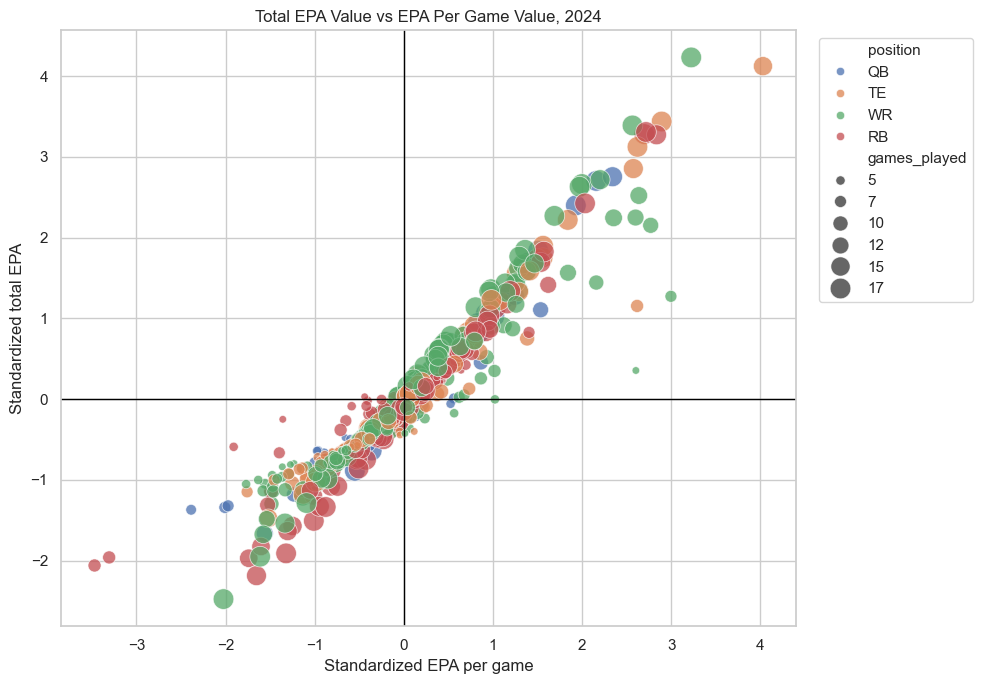

In [6]:
plot_df = value_scored[value_scored["season"] == season_to_check].copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=plot_df,
    x="value_score_per_game",
    y="value_score",
    hue="position",
    size="games_played",
    sizes=(30, 220),
    alpha=0.75
)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.title("Total EPA Value vs EPA Per Game Value, " + str(season_to_check))
plt.xlabel("Standardized EPA per game")
plt.ylabel("Standardized total EPA")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Top Player-Seasons Overall

This table ranks player-seasons by raw total EPA across the full dataset.

Because quarterbacks handle the ball on far more plays than RBs, WRs, or TEs, raw total EPA is not position-neutral. Use this table to understand overall production, but use position-specific tables and standardized scores when making within-position comparisons.


In [7]:
value_scored[[
    "season", "player_display_name", "position", "team", "games_played",
    "value_epa_total", "value_epa_per_game", "value_score",
    "value_score_per_game", "position_season_rank"
]].sort_values("value_epa_total", ascending=False).head(25)


,season,player_display_name,position,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game,position_season_rank
143,2018,Patrick Mahomes,QB,KC,16,237.035261,14.814704,3.281056,2.671036,1.0
336,2022,Patrick Mahomes,QB,KC,17,217.440698,12.790629,3.982687,2.901099,1.0
233,2020,Patrick Mahomes,QB,KC,15,203.585468,13.572365,2.729479,2.401074,1.0
188,2019,Lamar Jackson,QB,BAL,15,198.891739,13.259449,3.149791,2.525299,1.0
204,2020,Aaron Rodgers,QB,GB,16,189.192151,11.824509,2.502075,2.051111,2.0
451,2024,Josh Allen,QB,BUF,16,187.113574,11.694598,2.753053,2.341023,1.0
449,2024,Lamar Jackson,QB,BAL,17,183.931545,10.819503,2.701035,2.157571,2.0
536,2025,Drake Maye,QB,NE,17,176.374409,10.374965,3.051060,1.978936,1.0
241,2020,Josh Allen,QB,BUF,16,169.031357,10.564460,2.183548,1.798819,3.0
15,2016,Matt Ryan,QB,ATL,16,166.575950,10.410997,2.599548,1.985374,1.0


## Standardized Value Distribution By Position

This boxplot shows the spread of `value_score` by position. Since `value_score` is standardized within each season-position group, the typical player at each position should be near zero.

The most useful thing to look for is outliers and distribution shape. Wider spreads suggest that the gap between top and bottom performers is larger for that position. Extreme positive values can indicate truly dominant seasons, but they can also reflect skewed position distributions, especially for smaller or more specialized groups like tight ends.


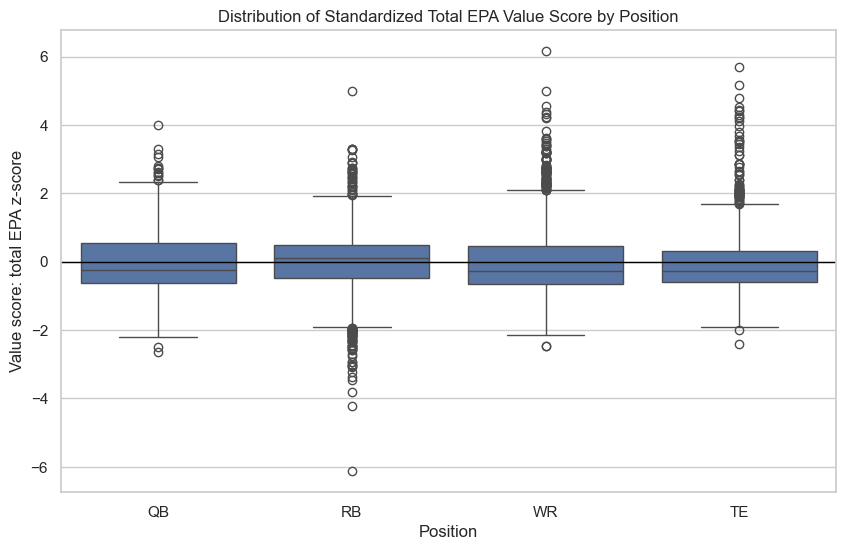

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=value_scored, x="position", y="value_score", order=["QB", "RB", "WR", "TE"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Distribution of Standardized Total EPA Value Score by Position")
plt.xlabel("Position")
plt.ylabel("Value score: total EPA z-score")
plt.show()


## Raw Total EPA Distribution By Position

This plot shows raw `value_epa_total` by position. Unlike `value_score`, this is still in EPA units and is therefore easier to explain: higher values mean more expected points added.

The main caveat is that raw EPA is naturally position-dependent. Quarterbacks usually have much higher total EPA because they are involved in far more plays. This is why the project keeps raw EPA for interpretability and standardized scores for fairer within-position comparison.


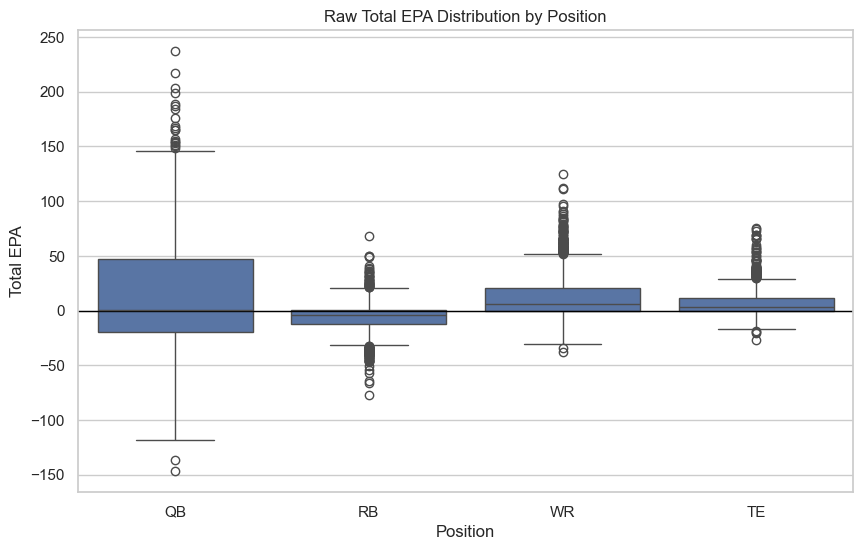

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=value_scored, x="position", y="value_epa_total", order=["QB", "RB", "WR", "TE"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Raw Total EPA Distribution by Position")
plt.xlabel("Position")
plt.ylabel("Total EPA")
plt.show()


## Age Curves By Position

This chart summarizes average standardized value by age and position. It is meant to show broad career-pattern signals rather than evaluate individual players.

Be careful with interpretation. This chart has survivorship bias: older players who remain in the league are usually better than the average player who entered the league at the same age. So if older ages look strong, that does not necessarily mean players improve indefinitely with age; weaker players may simply have left the dataset.


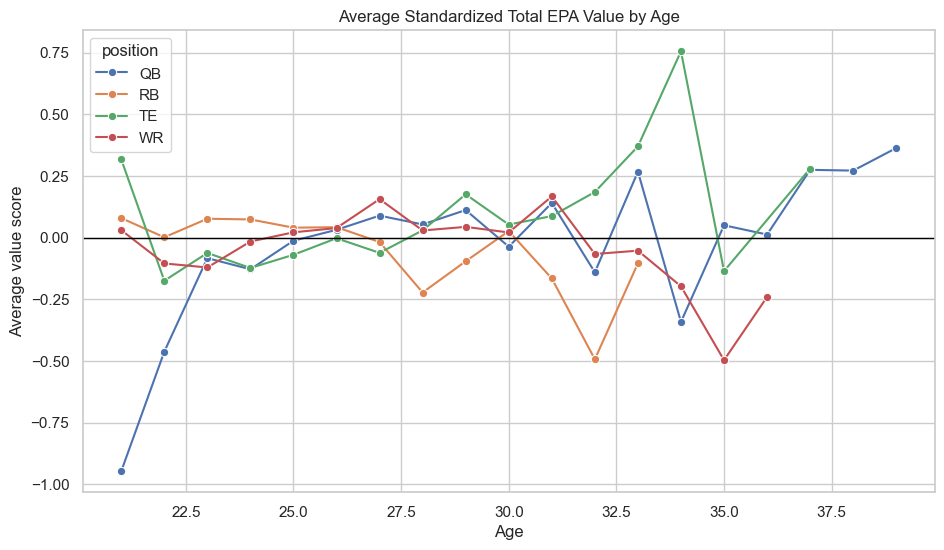

In [10]:
age_curve = (
    value_scored
    .dropna(subset=["age", "value_score"])
    .assign(age=lambda df: df["age"].round().astype(int))
    .groupby(["position", "age"], as_index=False)
    .agg(
        avg_value_score=("value_score", "mean"),
        avg_total_epa=("value_epa_total", "mean"),
        n=("player_id", "count")
    )
    .query("n >= 5")
)

plt.figure(figsize=(11, 6))
sns.lineplot(data=age_curve, x="age", y="avg_value_score", hue="position", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average Standardized Total EPA Value by Age")
plt.xlabel("Age")
plt.ylabel("Average value score")
plt.show()


## Experience Curves By Position

This chart uses `years_exp` to look at career-stage patterns. It asks whether players tend to produce more value early, in the middle of their careers, or later.

Like the age chart, this is descriptive rather than causal. Experience is related to talent, opportunity, health, and roster survival. Still, it is useful for later modeling because salary efficiency often depends heavily on career stage, especially rookie-contract seasons.


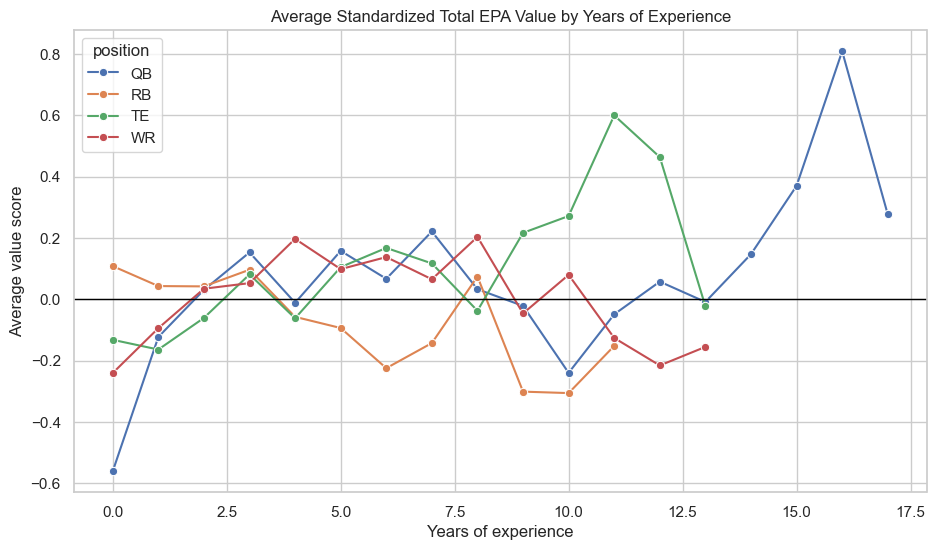

In [11]:
exp_curve = (
    value_scored
    .dropna(subset=["years_exp", "value_score"])
    .assign(years_exp=lambda df: df["years_exp"].round().astype(int))
    .groupby(["position", "years_exp"], as_index=False)
    .agg(
        avg_value_score=("value_score", "mean"),
        avg_total_epa=("value_epa_total", "mean"),
        n=("player_id", "count")
    )
    .query("n >= 5")
)

plt.figure(figsize=(11, 6))
sns.lineplot(data=exp_curve, x="years_exp", y="avg_value_score", hue="position", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Average Standardized Total EPA Value by Years of Experience")
plt.xlabel("Years of experience")
plt.ylabel("Average value score")
plt.show()


## Per-Game Outliers

This table highlights players whose per-game standardized score is much higher than their total-EPA standardized score.

These are important diagnostic cases. Some may be players who missed time but were excellent when active. Others may be lower-volume players whose per-game production looks strong but may not represent the same season-level value as a full-time player. This table helps keep the project honest about the limitations of rate stats.


In [12]:
value_scored[[
    "season", "player_display_name", "position", "team", "games_played",
    "value_epa_total", "value_epa_per_game", "value_score",
    "value_score_per_game", "value_score_gap"
]].sort_values("value_score_gap", ascending=False).head(25)


,season,player_display_name,position,team,games_played,value_epa_total,value_epa_per_game,value_score,value_score_per_game,value_score_gap
4374,2025,Tyreek Hill,WR,MIA,4,19.834595,4.958649,0.510285,3.125714,2.615429
4279,2024,Rashee Rice,WR,KC,4,18.822884,4.705721,0.353891,2.602922,2.249031
2701,2021,Maxx Williams,TE,ARI,5,15.071474,3.014295,0.660362,2.667580,2.007218
2414,2020,Kenny Golladay,WR,DET,5,21.662457,4.332491,0.329387,2.181860,1.852473
2642,2021,Antonio Brown,WR,TB,7,34.262215,4.894602,1.122572,2.849496,1.726924
3990,2024,Chris Godwin Jr.,WR,TB,7,37.047007,5.292430,1.272327,2.996180,1.723854
2060,2019,Will Dissly,TE,SEA,6,19.106299,3.184383,0.816342,2.527502,1.711160
4649,2025,Tucker Kraft,TE,GB,8,38.442761,4.805345,2.054956,3.671043,1.616086
4732,2025,Ashton Jeanty,RB,LV,17,-77.057753,-4.532809,-6.127502,-4.539718,1.587784
4711,2025,Jalen McMillan,WR,TB,4,12.027500,3.006875,0.091477,1.670289,1.578812


## Correlation With Supporting Statistics

The heatmap and correlation table show how the value metrics relate to supporting variables such as games played, yards, touchdowns, age, experience, and efficiency stats.

These correlations are descriptive, not causal. They are useful for feature selection and intuition before predictive modeling. For example, a strong relationship with games played would confirm that total EPA rewards availability, while a strong relationship with per-game efficiency metrics would show that the score is also capturing production quality.


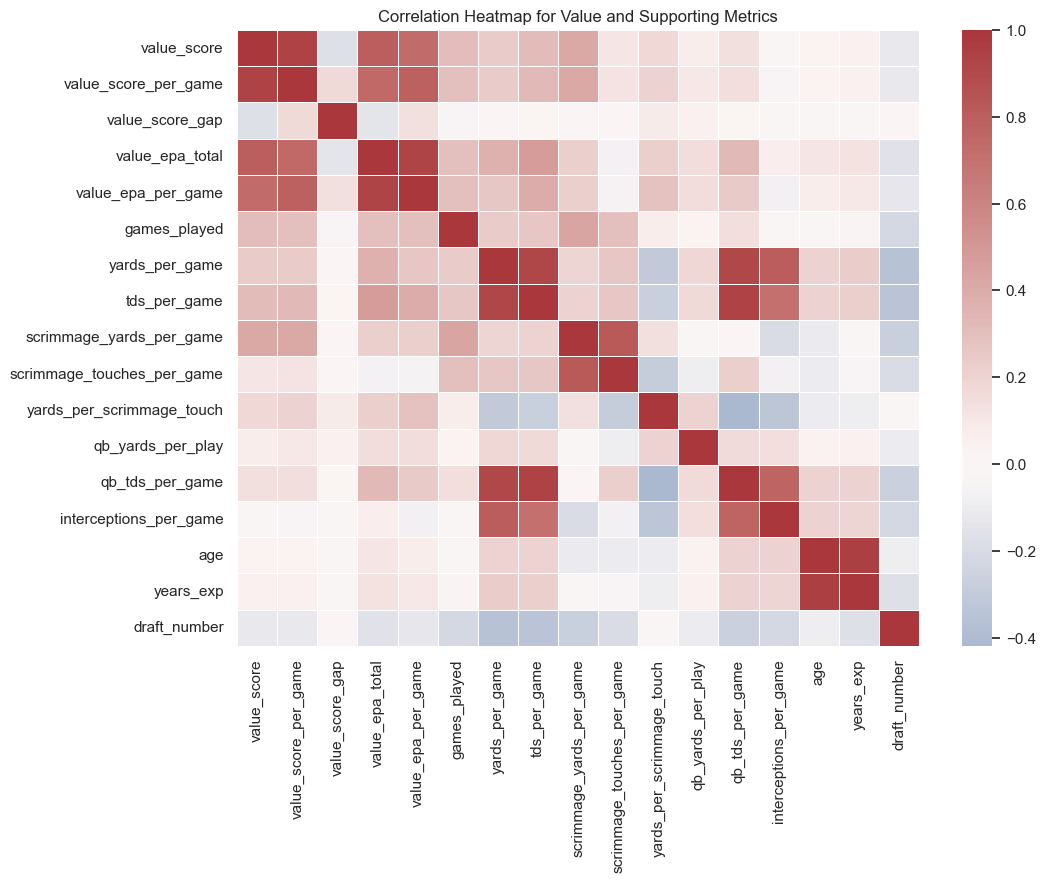

value_score                   1.000000
value_score_per_game          0.941705
value_epa_total               0.797178
value_epa_per_game            0.733790
scrimmage_yards_per_game      0.414660
tds_per_game                  0.314588
games_played                  0.310357
yards_per_game                0.237325
yards_per_scrimmage_touch     0.177166
qb_tds_per_game               0.137958
scrimmage_touches_per_game    0.115410
qb_yards_per_play             0.079040
years_exp                     0.054723
age                           0.033318
interceptions_per_game       -0.023846
draft_number                 -0.117653
value_score_gap              -0.170727
Name: value_score, dtype: float64

In [13]:
supporting_cols = [
    "value_score", "value_score_per_game", "value_score_gap",
    "value_epa_total", "value_epa_per_game", "games_played",
    "yards_per_game", "tds_per_game", "scrimmage_yards_per_game",
    "scrimmage_touches_per_game", "yards_per_scrimmage_touch",
    "qb_yards_per_play", "qb_tds_per_game", "interceptions_per_game",
    "age", "years_exp", "draft_number"
]

available_cols = [col for col in supporting_cols if col in value_scored.columns]

corr = value_scored[available_cols].corr(numeric_only=True)
plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation Heatmap for Value and Supporting Metrics")
plt.show()

corr["value_score"].sort_values(ascending=False)


## Methodological Notes

The current design separates raw production from standardized comparison.

- `value_epa_total` is the primary raw value metric because it measures full-season production.
- `value_epa_per_game` is the rate version because it measures production when active.
- `value_score` standardizes total EPA within season-position groups.
- `value_score_per_game` standardizes EPA per game within season-position groups.

This design is stronger than using EPA per game alone because it distinguishes total season contribution from per-game productivity.

The metrics are still production-based. They do not fully capture blocking, route quality, offensive scheme, offensive line effects, defensive attention, play-calling, or teammate effects. Tight ends are especially affected because blocking value is not represented well in the current data. These limitations should be revisited in the final report and salary-efficiency analysis.
